# Zoomcamp ML - 02 Linear regression homework

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
data = pd.read_csv("car_fuel_efficiency_2026.csv")

In [10]:
data.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [11]:
columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

In [12]:
df = data[columns]

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

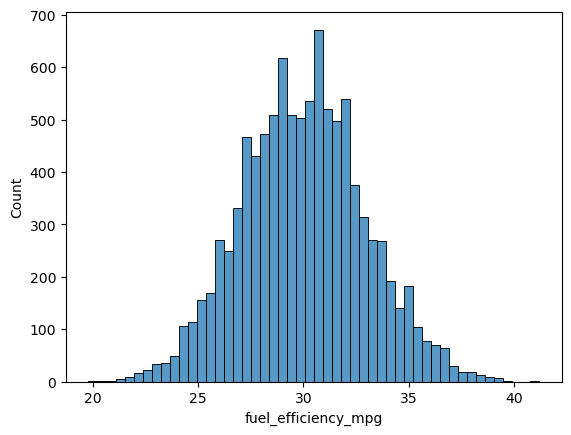

In [14]:
sns.histplot(data=df["fuel_efficiency_mpg"], bins=50)

fuel_efficiency_mpg has ccharacteristic bell shape, it is close to normal distribution. No long tail observed.

### Question 1
There's one column with missing values. What is it?

In [15]:
df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### Question 2
What's the median (50% percentile) for variable 'horsepower'?

In [16]:
df["horsepower"].median()

254.0

In [20]:
df["horsepower"].quantile(0.5)

254.0

### Prepare and split the dataset

In [17]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [22]:
y_train = df_train["fuel_efficiency_mpg"]
y_val = df_val["fuel_efficiency_mpg"]
y_test = df_test["fuel_efficiency_mpg"]

In [23]:
del df_train["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]

For Q5, repeat the same block with each listed seed. For Q6, use seed 9.

### Question 3
We need to deal with missing values for the column from Q1.  
We have two options: fill it with 0 or with the mean of this variable.  
Try both options. For each, train a linear regression model without regularization using the code from the lessons.  
For computing the mean, use the training only!  
Use the validation dataset to evaluate the models and compare the RMSE of each option.  
Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.  
Which option gives better RMSE?  

In [83]:
def train_linear_regression(X, y, include_reg=True, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    if include_reg:
        XTX = r * np.eye(XTX.shape[0]) + XTX
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [68]:
def prepare_data(df, fill_missing, target_column="fuel_efficiency_mpg"):
    data = df.copy()
    del data[target_column]
    return data.fillna(fill_missing).values

In [69]:
def rmse(y, y_pred):
    score = np.sqrt(np.mean((y - y_pred) ** 2))
    return round(score, 3)

In [70]:
X_zeros = prepare_data(df_train, 0)

w0, w = train_linear_regression(X_zeros, y_train, False)
y_zeros_pred = w0 + np.dot(X_zeros, w)
rmse(y_train, y_zeros_pred)

2.2

In [71]:
X_mean = prepare_data(df_train, df_train.mean())

w0_mean, w_mean = train_linear_regression(X_mean, y_train, False)
y_mean_pred = w0_mean + np.dot(X_mean, w_mean)
rmse(y_train, y_mean_pred)

2.199

Question 4
Now let's train a regularized linear regression.
For this question, fill the NAs with 0.
Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
Use RMSE to evaluate the model on the validation dataset.
Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
Which r gives the best RMSE?

In [72]:
X_train = prepare_data(df_train, 0)
X_val = prepare_data(df_val, 0)
regs = [0, 0.01, 0.1, 1, 5, 10, 100]

results = {}

for reg in regs:
    w0,w = train_linear_regression(X_train, y_train, True, reg)
    y_pred = w0 + X_val.dot(w)
    results[reg] = rmse(y_val, y_pred)

results, min(results, key=results.get)

({0: 2.207,
  0.01: 2.207,
  0.1: 2.207,
  1: 2.207,
  5: 2.207,
  10: 2.207,
  100: 2.207},
 0)

### Question 5
We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.  
Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].  
For each seed, do the train/validation/test split with 60%/20%/20% distribution.  
Fill the missing values with 0 and train a model without regularization.  
For each seed, evaluate the model on the validation dataset and collect the RMSE scores.  
What's the standard deviation of all the scores? To compute the standard deviation, use np.std.  
Round the result to 3 decimal digits (round(std, 3))  

In [89]:
def split_data(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test

In [87]:
def prepare_labels(df_train, df_val, df_test, target_column):
    return df_train[target_column], df_val[target_column], df_test[target_column]

In [88]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
target_column = "fuel_efficiency_mpg"
results_seed = {}
for s in seeds:
    df_train, df_val, df_test = split_data(df, s)
    y_train, y_val, y_test = prepare_labels(df_train, df_val, df_test, target_column)

    
    X_train = prepare_data(df_train, 0, target_column)
    X_val = prepare_data(df_val, 0, target_column)
    w0, w = train_linear_regression(X_train, y_train, False)
    y_val_pred = w0 + X_val.dot(w)
    results_seed[s] = rmse(y_val, y_val_pred)

round(np.std(list(results_seed.values())), 3)

TypeError: split_data() takes 1 positional argument but 2 were given

In [79]:
results_seed

{0: 2.239,
 1: 2.202,
 2: 2.163,
 3: 2.204,
 4: 2.202,
 5: 2.246,
 6: 2.27,
 7: 2.191,
 8: 2.217,
 9: 2.207}

### Question 6
Split the dataset like previously, use seed 9.  
Combine train and validation datasets.  
Fill the missing values with 0 and train a model with r=0.001.  
What's the RMSE on the test dataset?  

In [92]:
target_column = "fuel_efficiency_mpg"

df_train, df_val, df_test = split_data(df, 9)
y_train, y_val, y_test = prepare_labels(df_train, df_val, df_test, target_column)

df_train_full = pd.concat([df_train, df_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

X_train_full = prepare_data(df_train_full, 0, target_column)
X_test = prepare_data(df_test, 0, target_column)
w0, w = train_linear_regression(X_train_full, y_train_full, True, 0.001)
y_test_pred = w0 + X_test.dot(w)
rmse(y_test, y_test_pred)

2.236